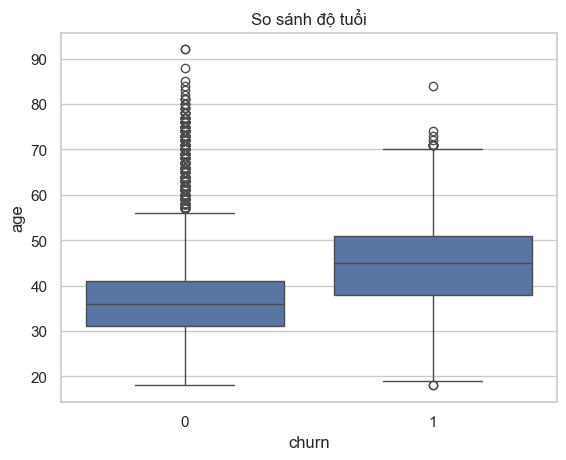

Text(0.5, 1.0, 'Phân phối số dư')

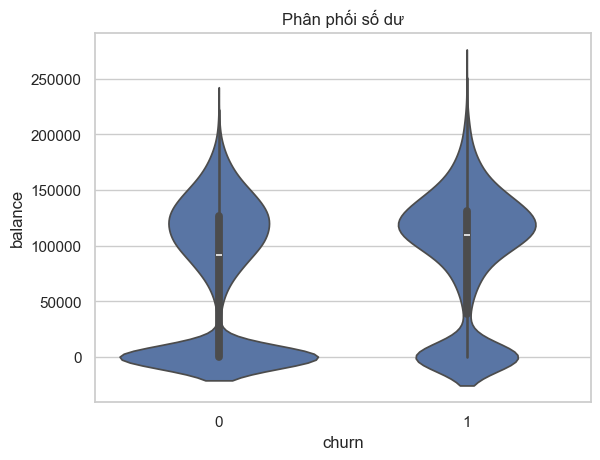

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')
df.columns = df.columns.str.strip()

# Boxplot Age
sns.boxplot(x='churn', y='age', data=df)
plt.title('So sánh độ tuổi')
plt.show()

# Violin Balance
sns.violinplot(x='churn', y='balance', data=df)
plt.title('Phân phối số dư')

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')


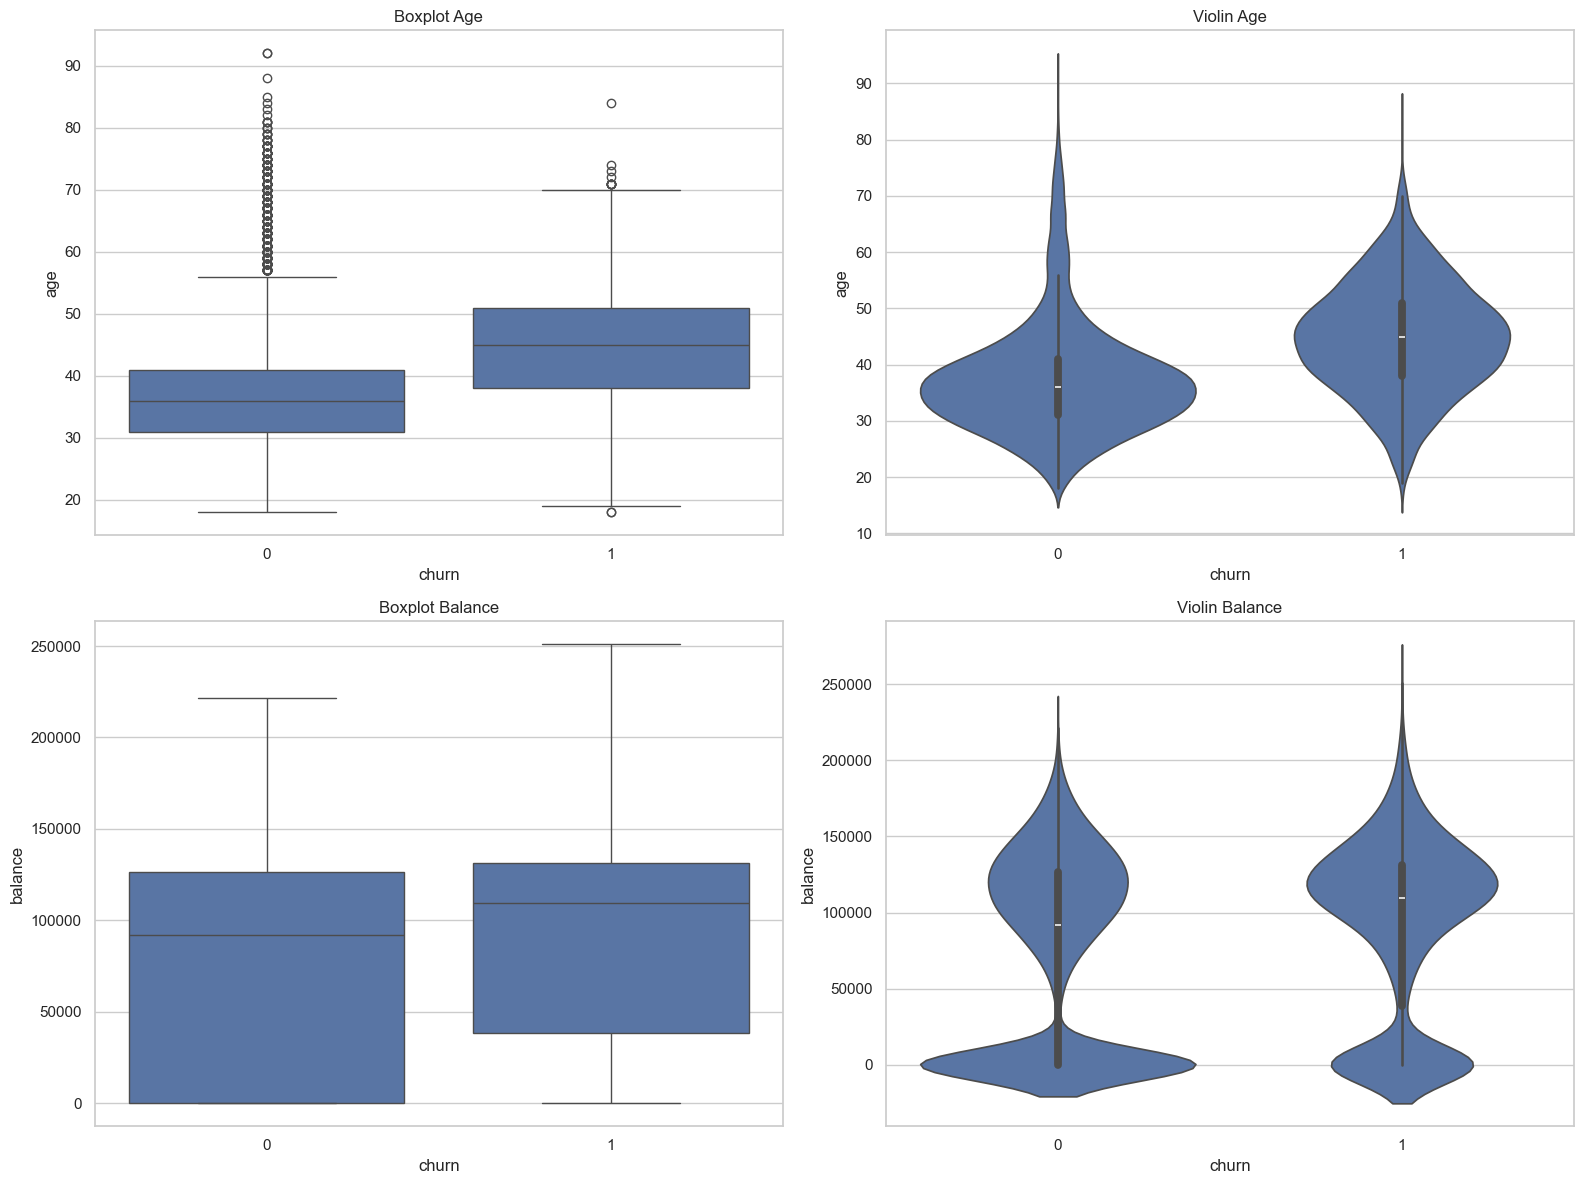

In [ ]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv') #Đọc file CSV vào DataFrame df


# Chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.lower()   # xóa khoảng trắng và chuyển về chữ thường 

print(df.columns)  # kiểm tra 

# Tạo layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))   #fig toàn bộ khung hình axes là trận 4 vị trí

# AGE
sns.boxplot(data=df, x='churn', y='age', ax=axes[0,0])  
axes[0,0].set_title('Boxplot Age')

sns.violinplot(data=df, x='churn', y='age', ax=axes[0,1])  #Khách ở lại (churn = 0)
                                                           #Khách rời đi (churn = 1)
axes[0,1].set_title('Violin Age')

# BALANCE
sns.boxplot(data=df, x='churn', y='balance', ax=axes[1,0])
axes[1,0].set_title('Boxplot Balance')

sns.violinplot(data=df, x='churn', y='balance', ax=axes[1,1])
axes[1,1].set_title('Violin Balance')

plt.tight_layout()    #Tự động căn chỉnh
plt.show()            #Hiển thị biểu đồ

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')
Cột trong dữ liệu:
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

Kiểu dữ liệu:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object
             age       balance
churn                         
0      37.408389  72745.296779
1      44.837997  91108.539337


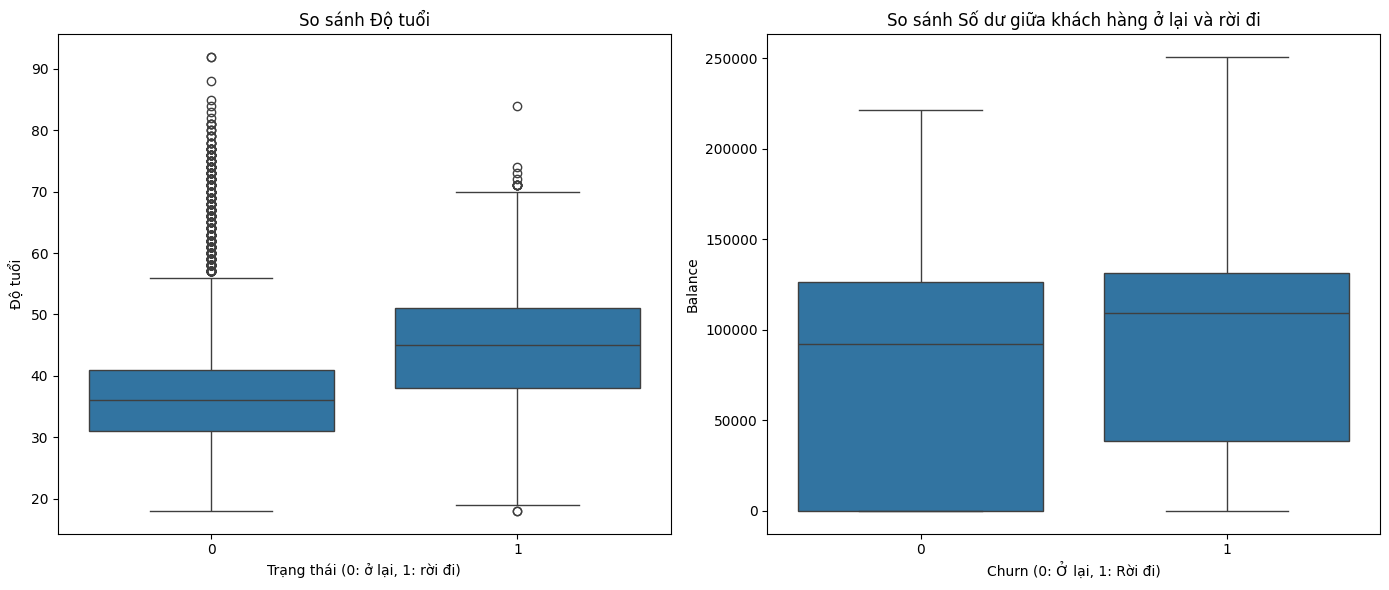

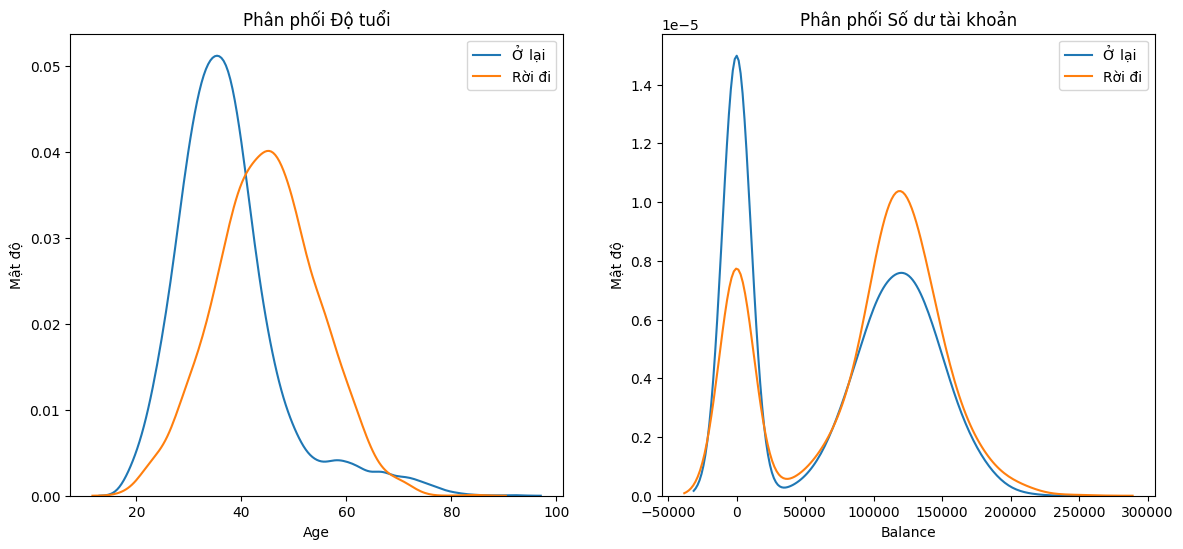

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dữ liệu
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')

# Fix tên cột
df.columns = df.columns.str.strip()

# Kiểm tra nhanh
print(df.columns)
# Thống kê
print("Cột trong dữ liệu:")
print(df.columns)

print("\nKiểu dữ liệu:")
print(df.dtypes)

# Fix khoảng trắng
df.columns = df.columns.str.strip()

# Thử lại
comparison_stats = df.groupby('churn')[['age', 'balance']].mean()
print(comparison_stats)
# Boxplot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='churn', y='age', data=df)
plt.title('So sánh Độ tuổi')
plt.xlabel('Trạng thái (0: ở lại, 1: rời đi)')
plt.ylabel('Độ tuổi')

plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('So sánh Số dư giữa khách hàng ở lại và rời đi')
plt.xlabel('Churn (0: Ở lại, 1: Rời đi)')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

# KDE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(df[df['churn'] == 0]['age'], label='Ở lại')
sns.kdeplot(df[df['churn'] == 1]['age'], label='Rời đi')

plt.title('Phân phối Độ tuổi')
plt.xlabel('Age')
plt.ylabel('Mật độ')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(df[df['churn'] == 0]['balance'], label='Ở lại')
sns.kdeplot(df[df['churn'] == 1]['balance'], label='Rời đi')

plt.title('Phân phối Số dư tài khoản')
plt.xlabel('Balance')
plt.ylabel('Mật độ')
plt.legend()

plt.show()



=== GIÁ TRỊ TRUNG BÌNH ===
             age       balance
churn                         
0      37.408389  72745.296779
1      44.837997  91108.539337

=== PHƯƠNG SAI ===
              age       balance
churn                          
0      102.522974  3.949876e+09
1       95.288084  3.405982e+09


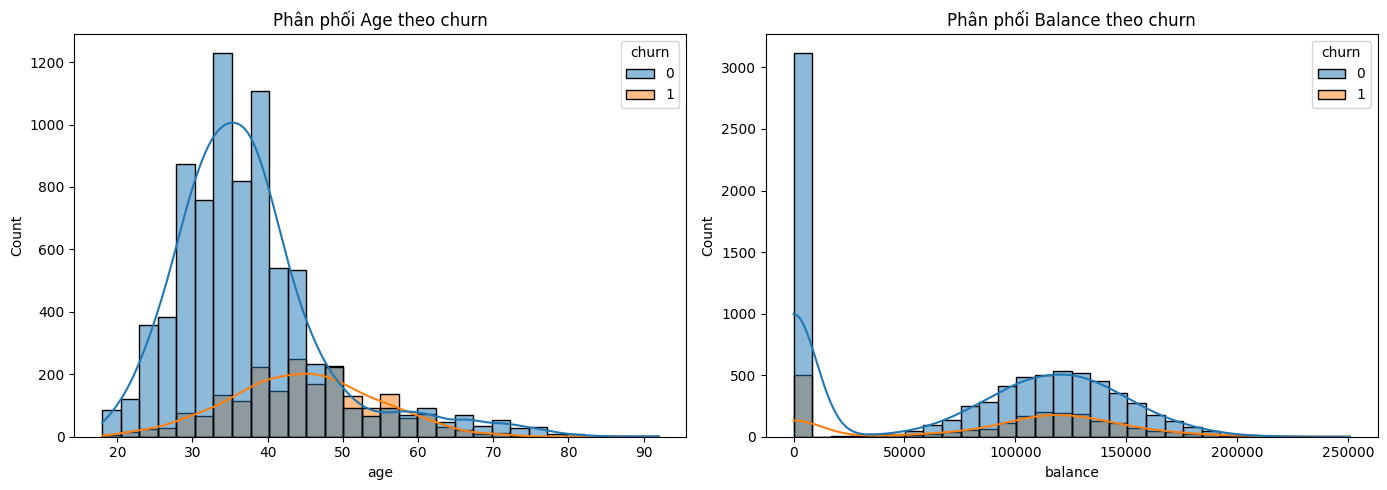

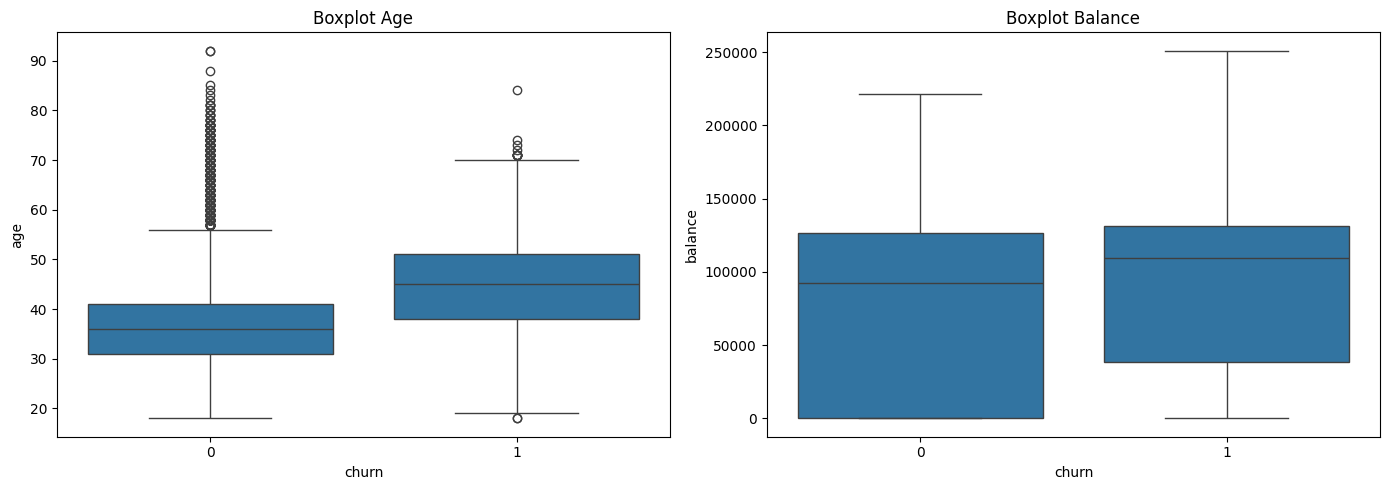

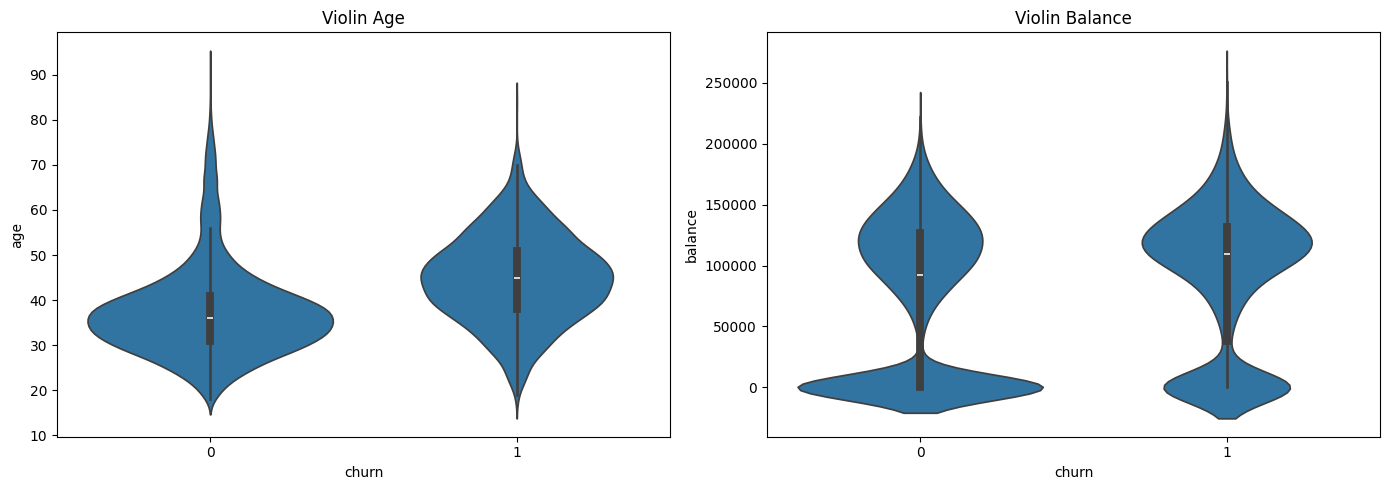

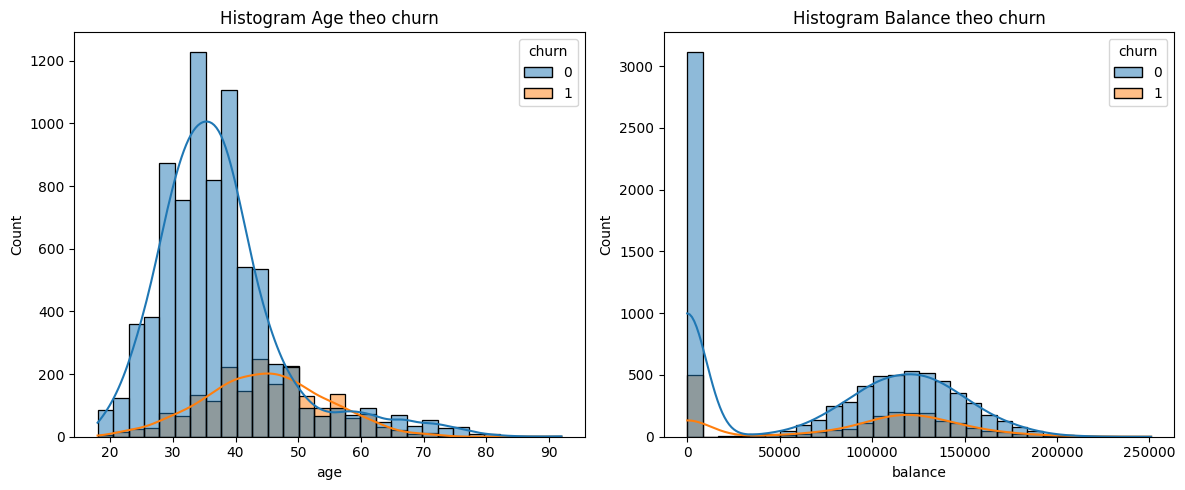

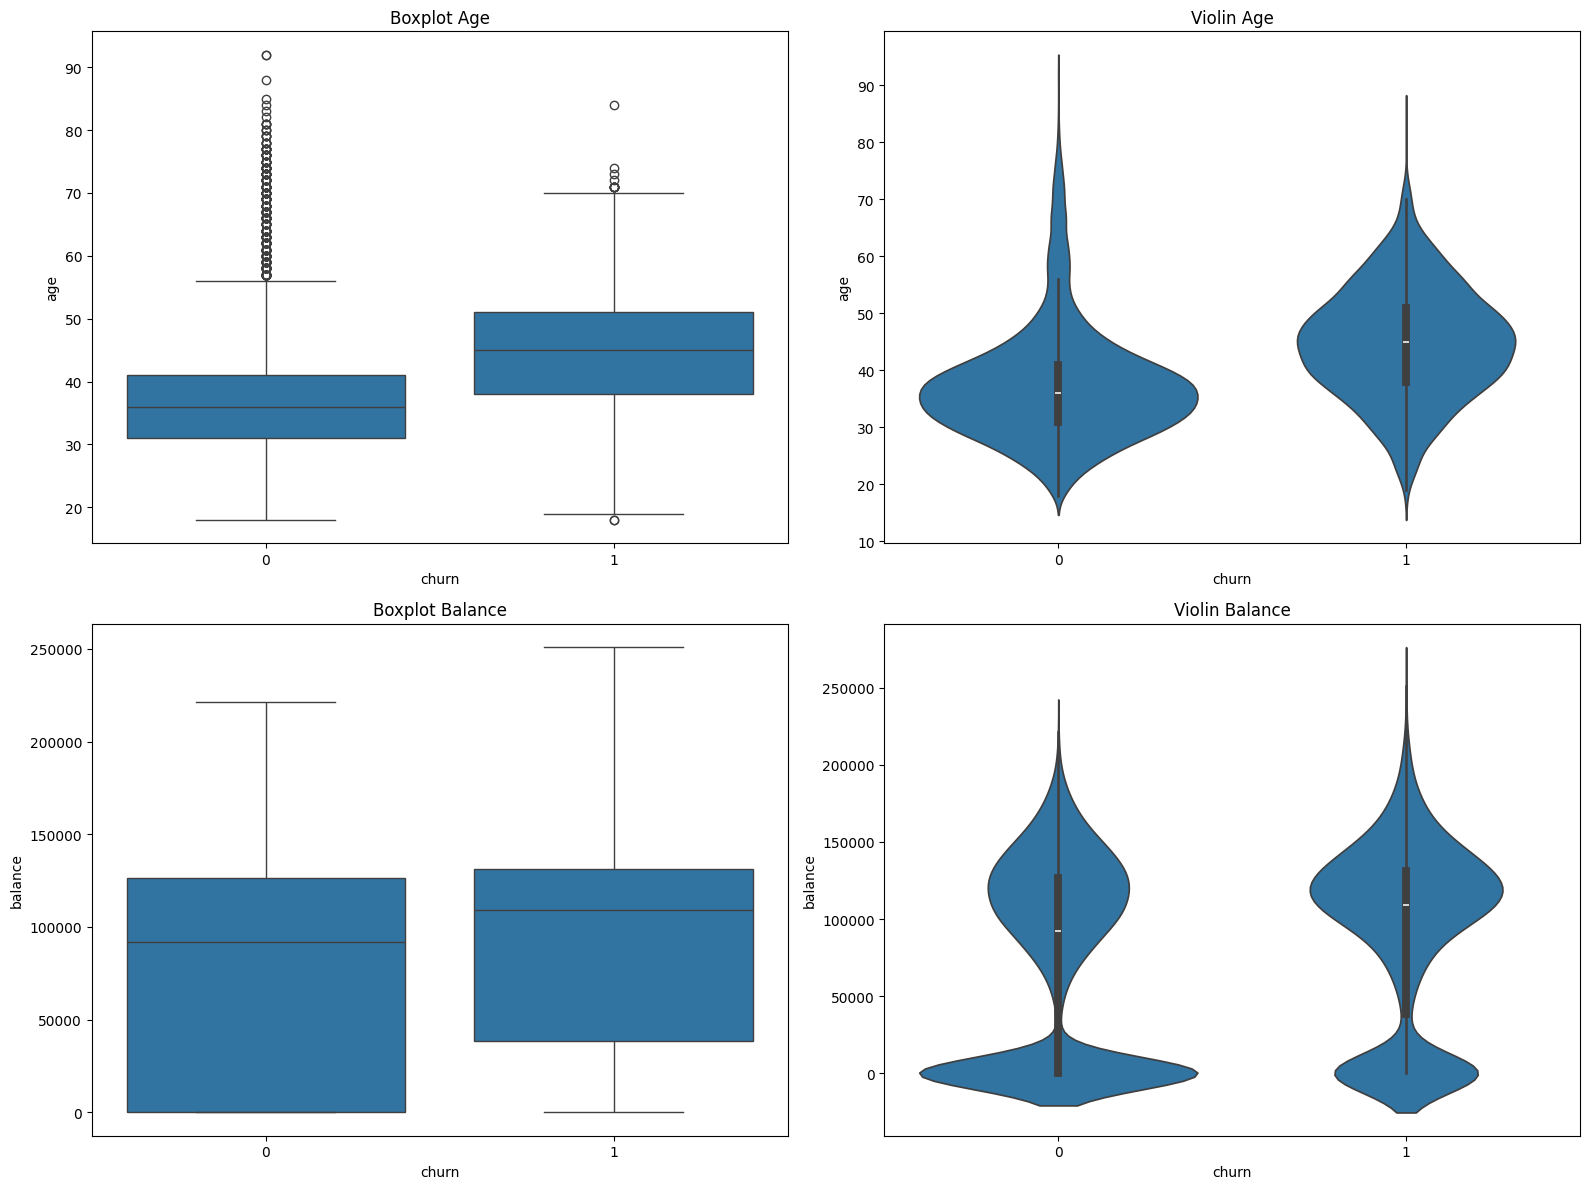

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 1. Đọc dữ liệu
# ==============================
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')

# ==============================
# 2. So sánh giá trị trung bình
# ==============================
print("=== GIÁ TRỊ TRUNG BÌNH ===")
mean_values = df.groupby('churn')[['age', 'balance']].mean()
print(mean_values)

# ==============================
# 3. So sánh phương sai
# ==============================
print("\n=== PHƯƠNG SAI ===")
var_values = df.groupby('churn')[['age', 'balance']].var()
print(var_values)
# Nếu dataset dùng 'Exited' thì đổi tên
if 'Exited' in df.columns:
    df.rename(columns={'Exited': 'churn'}, inplace=True)

# ==============================
# Histogram (so sánh phân phối tổng quan)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title('Phân phối Age theo churn')

# Balance
plt.subplot(1,2,2)
sns.histplot(data=df, x='balance', hue='churn', bins=30, kde=True)
plt.title('Phân phối Balance theo churn')

plt.tight_layout()
plt.show()

# ==============================
# Boxplot (so sánh median + outlier)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.boxplot(x='churn', y='age', data=df)
plt.title('Boxplot Age')

# Balance
plt.subplot(1,2,2)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Boxplot Balance')

plt.tight_layout()
plt.show()

# ==============================
#  Violin plot (so sánh mật độ phân phối)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.violinplot(x='churn', y='age', data=df)
plt.title('Violin Age')

# Balance
plt.subplot(1,2,2)
sns.violinplot(x='churn', y='balance', data=df)
plt.title('Violin Balance')

plt.tight_layout()
plt.show()
# ==============================
# 4. Histogram (theo churn)
# ==============================
plt.figure(figsize=(12,5))

# Age
plt.subplot(1,2,1)
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title('Histogram Age theo churn')

# Balance
plt.subplot(1,2,2)
sns.histplot(data=df, x='balance', hue='churn', bins=30, kde=True)
plt.title('Histogram Balance theo churn')

plt.tight_layout()
plt.show()

# ==============================
# 5. Boxplot + Violin (4 biểu đồ)
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# AGE
sns.boxplot(data=df, x='churn', y='age', ax=axes[0,0])
axes[0,0].set_title('Boxplot Age')

sns.violinplot(data=df, x='churn', y='age', ax=axes[0,1])
axes[0,1].set_title('Violin Age')

# BALANCE
sns.boxplot(data=df, x='churn', y='balance', ax=axes[1,0])
axes[1,0].set_title('Boxplot Balance')

sns.violinplot(data=df, x='churn', y='balance', ax=axes[1,1])
axes[1,1].set_title('Violin Balance')

plt.tight_layout()
plt.show()